In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib, os

print("✅ Imports OK")

✅ Imports OK


In [2]:
df = pd.read_csv("salesdaily.csv", sep=";")
df["datum"] = pd.to_datetime(df["datum"])
df = df.sort_values("datum").set_index("datum")

cols = ["M01AB", "M01AE", "N02BA", "N02BE", "N05B", "N05C", "R03", "R06"]
df_daily = df[cols].copy()

print(f"Données journalières : {df_daily.shape}")
print(f"Période : {df_daily.index.min()} → {df_daily.index.max()}")
df_daily.head()

Données journalières : (2106, 8)
Période : 2014-01-02 00:00:00 → 2019-10-08 00:00:00


,M01AB,M01AE,N02BA,N02BE,N05B,N05C,R03,R06
datum,,,,,,,,
2014-01-02,0.0,3.67,3.4,32.40,7.0,0.0,0.0,2.0
2014-01-03,8.0,4.00,4.4,50.60,16.0,0.0,20.0,4.0
2014-01-04,2.0,1.00,6.5,61.85,10.0,0.0,9.0,1.0
2014-01-05,4.0,3.00,7.0,41.10,8.0,0.0,3.0,0.0
2014-01-06,5.0,1.00,4.5,21.70,16.0,2.0,6.0,2.0


In [3]:
# ── Vérification des valeurs manquantes ──────────────────────────
print("=== Valeurs manquantes par colonne ===")
print(df_daily.isnull().sum())
print(f"\nTotal : {df_daily.isnull().sum().sum()} valeurs manquantes")

# ── Vérification des doublons ─────────────────────────────────────
print("\n=== Doublons ===")
print(f"Lignes dupliquées : {df_daily.duplicated().sum()}")

# ── Résultat global ───────────────────────────────────────────────
if df_daily.isnull().sum().sum() == 0 and df_daily.duplicated().sum() == 0:
    print("\n✅ Aucun problème détecté — données propres !")
else:
    print("\n⚠️  Des problèmes ont été détectés — traitement nécessaire !")

=== Valeurs manquantes par colonne ===
M01AB    0
M01AE    0
N02BA    0
N02BE    0
N05B     0
N05C     0
R03      0
R06      0
dtype: int64

Total : 0 valeurs manquantes

=== Doublons ===
Lignes dupliquées : 25

⚠️  Des problèmes ont été détectés — traitement nécessaire !


In [4]:
# Vérification
print(f"Lignes avant suppression : {len(df_daily)}")

# Suppression des doublons sur l'index (la date)
df_daily = df_daily[~df_daily.index.duplicated(keep='first')]

# Vérification après — on vérifie l'INDEX cette fois
print(f"\nLignes après suppression  : {len(df_daily)}")
print(f"Doublons restants         : {df_daily.index.duplicated().sum()}")

if df_daily.index.duplicated().sum() == 0:
    print("✅ Doublons supprimés — données propres !")
else:
    print("⚠️ Encore des doublons !")

Lignes avant suppression : 2106

Lignes après suppression  : 2106
Doublons restants         : 0
✅ Doublons supprimés — données propres !


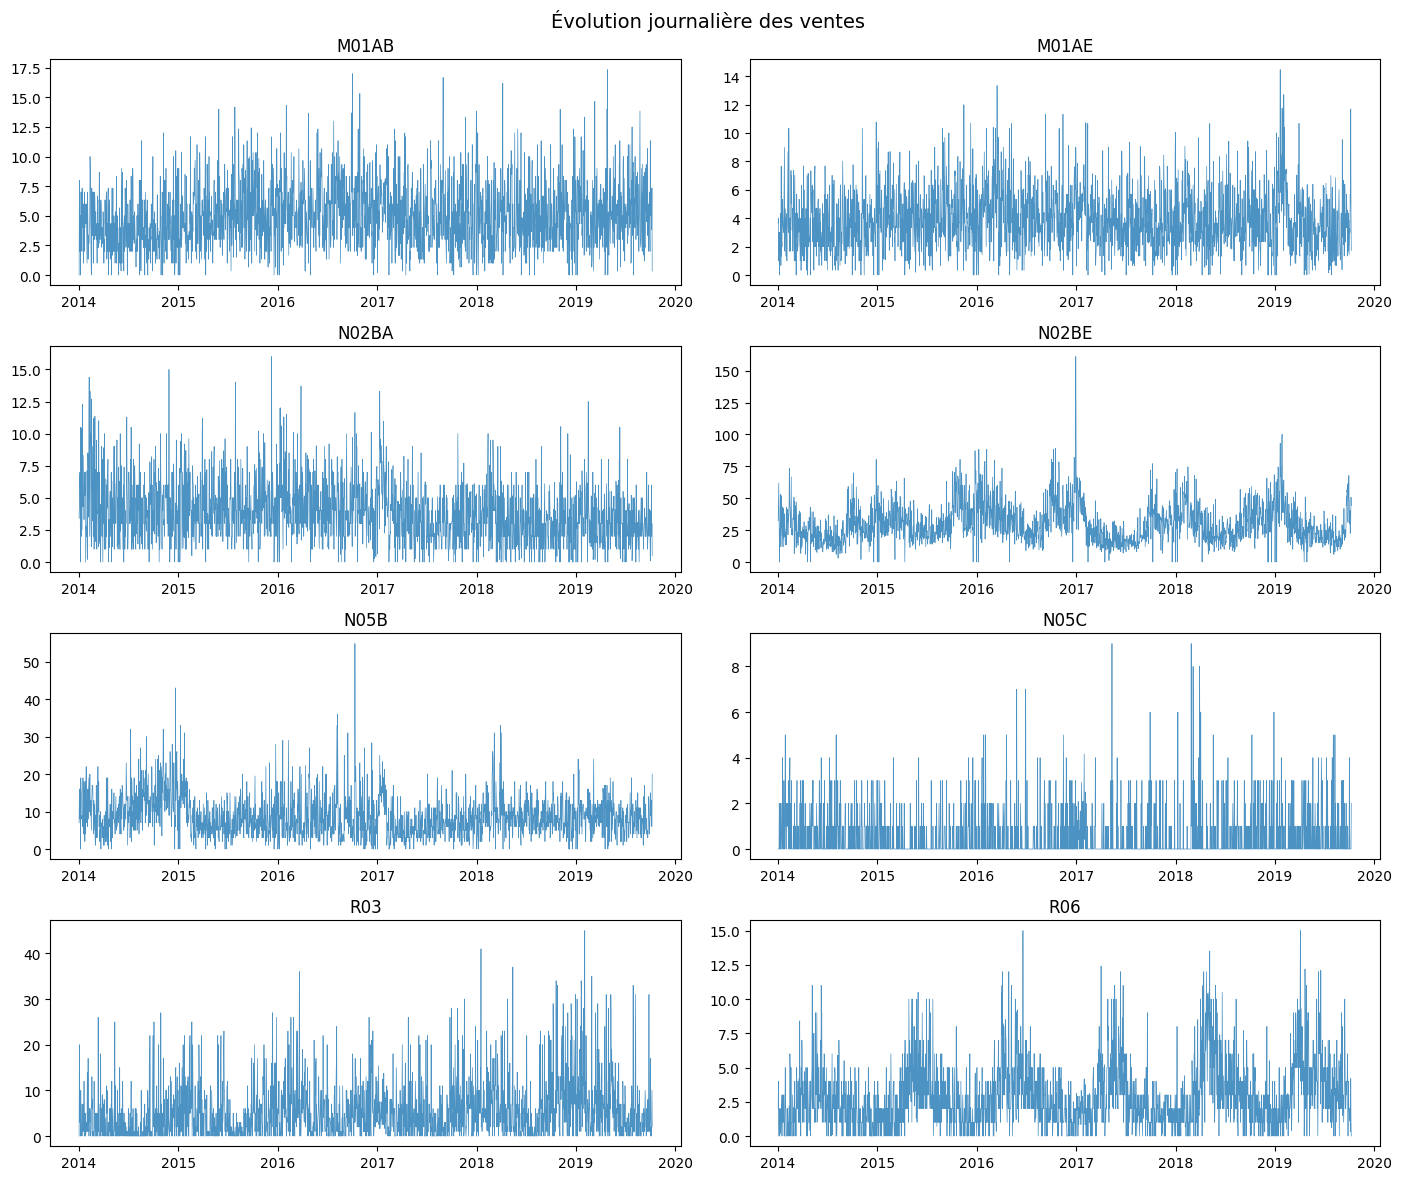

In [5]:
# Évolution journalière des ventes
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    axes[i].plot(df_daily.index, df_daily[col], linewidth=0.5, alpha=0.8)
    axes[i].set_title(col)
    axes[i].set_xlabel("")

plt.suptitle("Évolution journalière des ventes", fontsize=14)
plt.tight_layout()
plt.show()

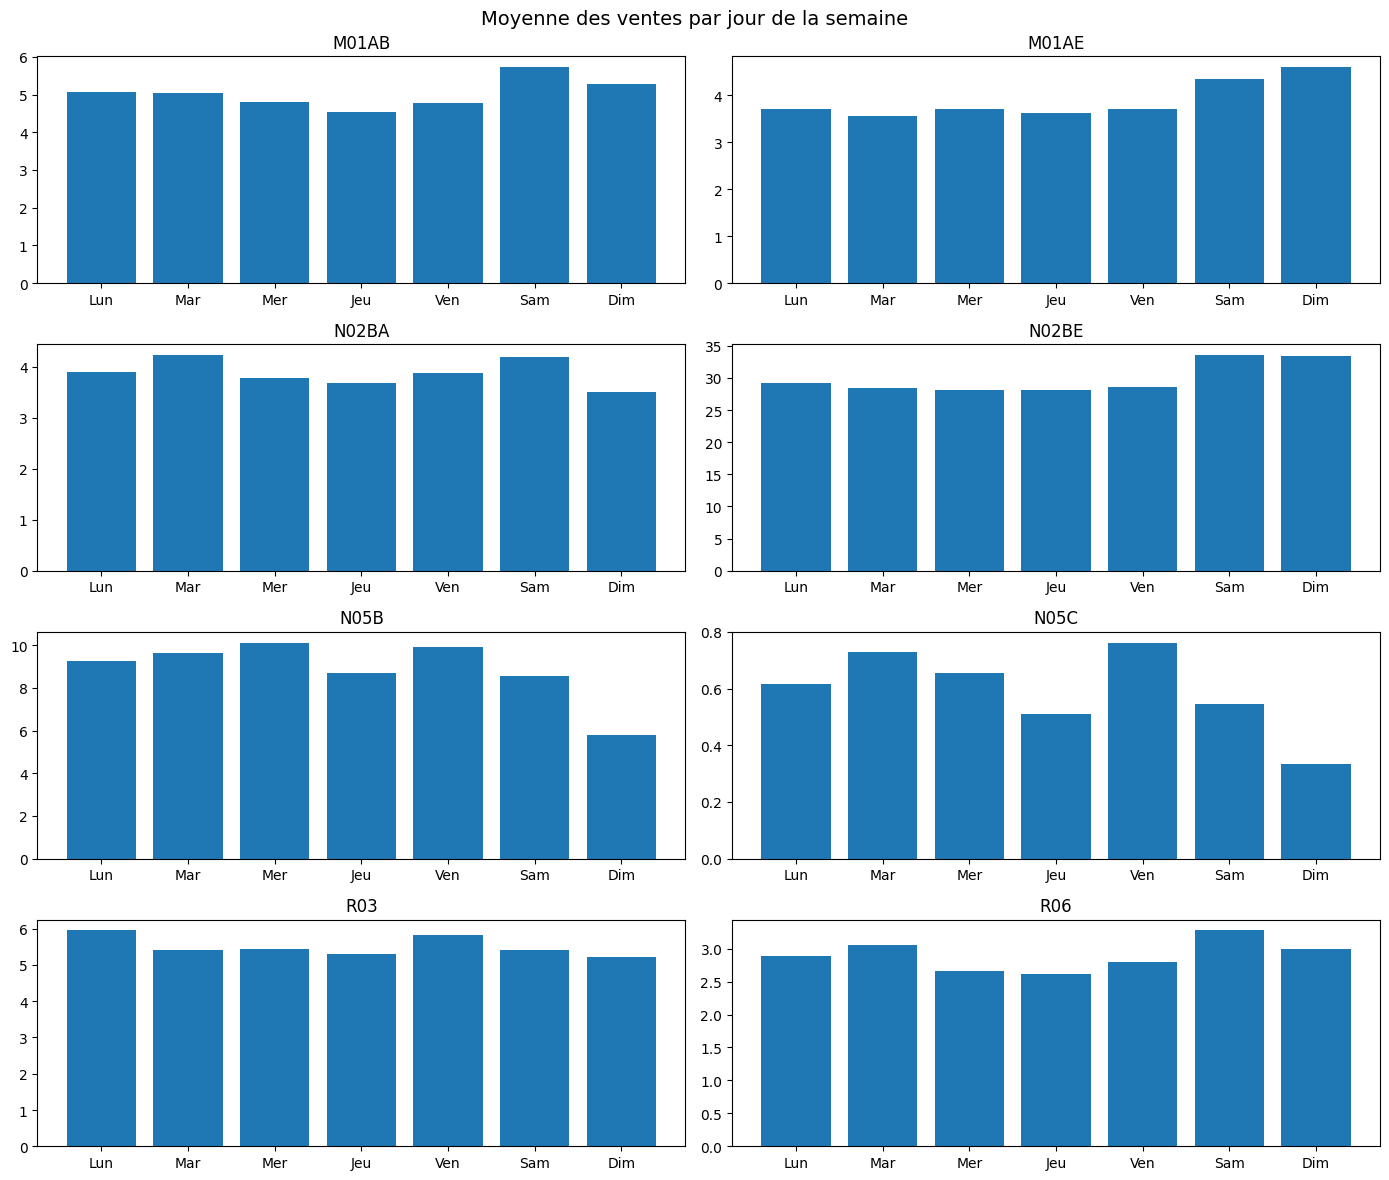

In [6]:
# Saisonnalité par jour de la semaine
df_dow = df_daily.copy()
df_dow["dayofweek"] = df_dow.index.dayofweek

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    avg = df_dow.groupby("dayofweek")[col].mean()
    axes[i].bar(["Lun","Mar","Mer","Jeu","Ven","Sam","Dim"], avg)
    axes[i].set_title(col)

plt.suptitle("Moyenne des ventes par jour de la semaine", fontsize=14)
plt.tight_layout()
plt.show()

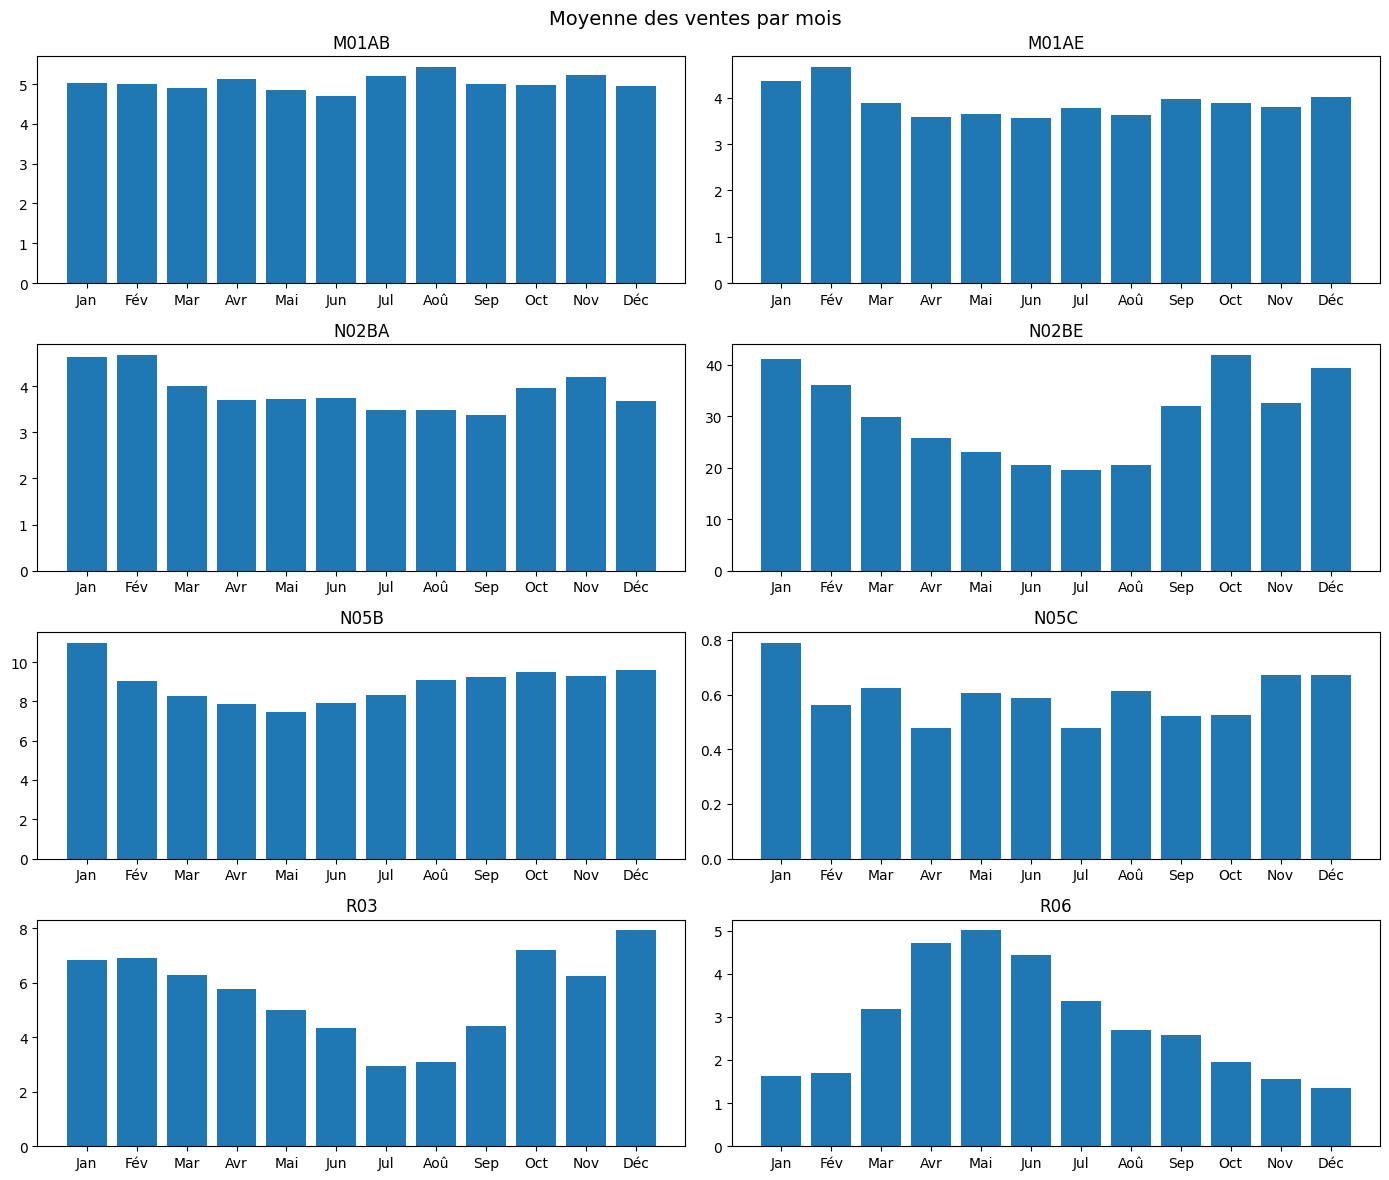

In [7]:
# Saisonnalité par mois
df_month = df_daily.copy()
df_month["month"] = df_month.index.month

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(cols):
    avg = df_month.groupby("month")[col].mean()
    axes[i].bar(range(1, 13), avg)
    axes[i].set_title(col)
    axes[i].set_xticks(range(1, 13))
    axes[i].set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun",
                              "Jul","Aoû","Sep","Oct","Nov","Déc"])

plt.suptitle("Moyenne des ventes par mois", fontsize=14)
plt.tight_layout()
plt.show()

In [8]:
# Features temporelles + lags journaliers
def create_features(df, target, lags=7):
    df_feat = df[[target]].copy()
    df_feat["dayofweek"]  = df_feat.index.dayofweek   # 0=Lundi ... 6=Dimanche
    df_feat["dayofmonth"] = df_feat.index.day
    df_feat["month"]      = df_feat.index.month
    df_feat["year"]       = df_feat.index.year
    df_feat["dayofyear"]  = df_feat.index.dayofyear
    # Lags J-1 à J-7
    for lag in range(1, lags + 1):
        df_feat[f"lag{lag}"] = df_feat[target].shift(lag)
    # Moyenne mobile 7 jours
    df_feat["rolling7"] = df_feat[target].shift(1).rolling(7).mean()
    df_feat = df_feat.dropna()
    return df_feat

feature_cols = ["dayofweek", "dayofmonth", "month", "year", "dayofyear",
                "lag1", "lag2", "lag3", "lag4", "lag5", "lag6", "lag7", "rolling7"]

print("Features utilisées :", feature_cols)
print("Exemple pour N02BE :")
create_features(df_daily, "N02BE").head()

Features utilisées : ['dayofweek', 'dayofmonth', 'month', 'year', 'dayofyear', 'lag1', 'lag2', 'lag3', 'lag4', 'lag5', 'lag6', 'lag7', 'rolling7']
Exemple pour N02BE :


,N02BE,dayofweek,dayofmonth,month,year,dayofyear,lag1,lag2,lag3,lag4,lag5,lag6,lag7,rolling7
datum,,,,,,,,,,,,,,
2014-01-09,25.0,3,9,1,2014,9,26.4,0.0,21.7,41.1,61.85,50.60,32.40,33.435714
2014-01-10,53.3,4,10,1,2014,10,25.0,26.4,0.0,21.7,41.10,61.85,50.60,32.378571
2014-01-11,52.3,5,11,1,2014,11,53.3,25.0,26.4,0.0,21.70,41.10,61.85,32.764286
2014-01-12,12.0,6,12,1,2014,12,52.3,53.3,25.0,26.4,0.00,21.70,41.10,31.400000
2014-01-13,52.0,0,13,1,2014,13,12.0,52.3,53.3,25.0,26.40,0.00,21.70,27.242857


In [9]:
from xgboost import XGBRegressor

models = {}

for target in cols:
    df_feat = create_features(df_daily, target, lags=7)

    X = df_feat[feature_cols]
    y = df_feat[target]

    # Split temporel : 80% train, 20% test
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    model = XGBRegressor(n_estimators=400,learning_rate=0.05,
        max_depth=6,
        random_state=42)

    model.fit(X_train, y_train)

    models[target] = {"model": model, "X_test": X_test, "y_test": y_test}
    print(f"✅ Modèle entraîné pour {target} | Train: {len(X_train)} jours | Test: {len(X_test)} jours")

print("Tous les modèles sont prêts !")

✅ Modèle entraîné pour M01AB | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour M01AE | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour N02BA | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour N02BE | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour N05B | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour N05C | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour R03 | Train: 1679 jours | Test: 420 jours
✅ Modèle entraîné pour R06 | Train: 1679 jours | Test: 420 jours
Tous les modèles sont prêts !


In [10]:
print("=== Évaluation des modèles (prédiction journalière) ===")

for target in cols:
    model  = models[target]["model"]
    X_test = models[target]["X_test"]
    y_test = models[target]["y_test"]
    y_pred = model.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    print(f"{target} → MAE: {mae:.2f} | RMSE: {rmse:.2f}")

=== Évaluation des modèles (prédiction journalière) ===
M01AB → MAE: 2.36 | RMSE: 2.98
M01AE → MAE: 1.72 | RMSE: 2.27
N02BA → MAE: 1.69 | RMSE: 2.16
N02BE → MAE: 9.56 | RMSE: 12.60
N05B → MAE: 3.38 | RMSE: 4.23
N05C → MAE: 0.87 | RMSE: 1.23
R03 → MAE: 6.18 | RMSE: 8.73
R06 → MAE: 1.69 | RMSE: 2.23


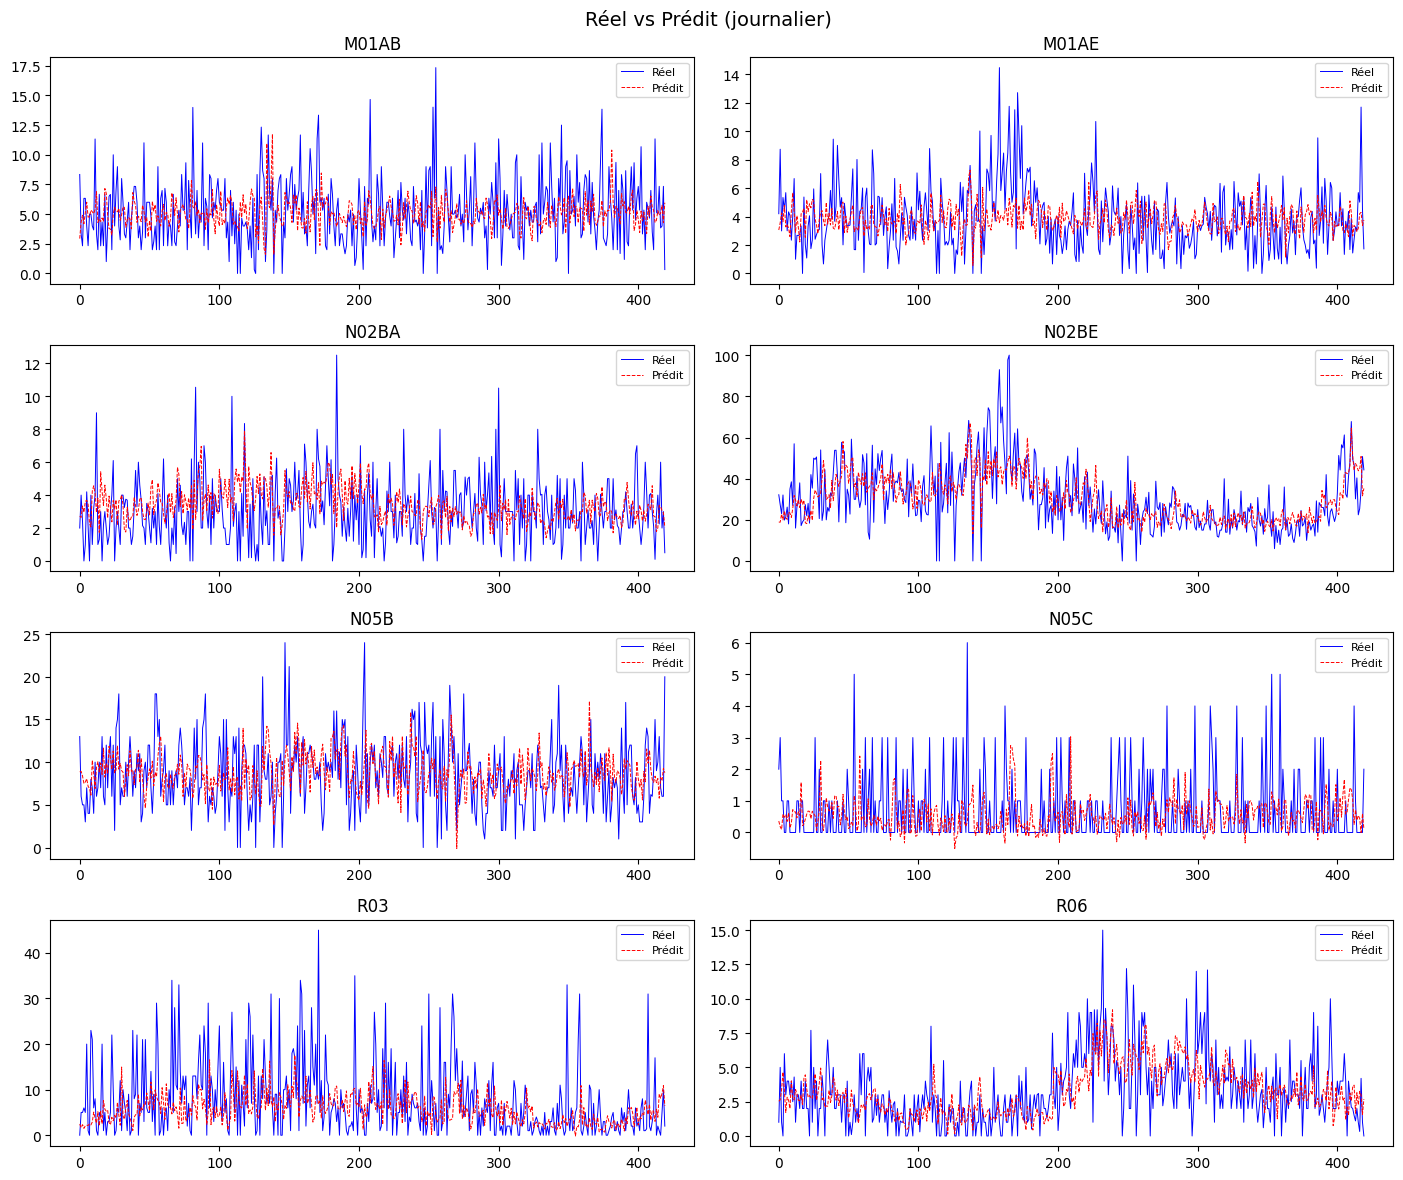

In [11]:
# Graphique Réel vs Prédit
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()

for i, target in enumerate(cols):
    y_pred = models[target]["model"].predict(models[target]["X_test"])
    axes[i].plot(models[target]["y_test"].values, label="Réel",  color="blue", linewidth=0.7)
    axes[i].plot(y_pred,                           label="Prédit", color="red",  linewidth=0.7, linestyle="--")
    axes[i].set_title(target)
    axes[i].legend(fontsize=8)

plt.suptitle("Réel vs Prédit (journalier)", fontsize=14)
plt.tight_layout()
plt.show()

In [12]:
# Prédire les ventes du jour suivant pour chaque médicament
print("=== Prédiction J+1 & Recommandations de réapprovisionnement ===")

last_date = df_daily.index[-1]
next_date = last_date + pd.Timedelta(days=1)
print(f"Dernière date connue : {last_date.date()}")
print(f"Date prédite         : {next_date.date()}")

for target in cols:
    last_vals = df_daily[target].values

    rolling7 = np.mean(last_vals[-7:])
    X_next = pd.DataFrame([{
        "dayofweek" : next_date.dayofweek,
        "dayofmonth": next_date.day,
        "month"     : next_date.month,
        "year"      : next_date.year,
        "dayofyear" : next_date.dayofyear,
        "lag1": last_vals[-1],  "lag2": last_vals[-2],
        "lag3": last_vals[-3],  "lag4": last_vals[-4],
        "lag5": last_vals[-5],  "lag6": last_vals[-6],
        "lag7": last_vals[-7],  "rolling7": rolling7
    }])

    prediction = models[target]["model"].predict(X_next)[0]
    seuil = prediction * 1.2

    print(f"{target}:")
    print(f"   Ventes prévues J+1         : {prediction:.1f} unités")
    print(f"   Stock minimum recommandé   : {seuil:.1f} unités (+20%)")
    print()

=== Prédiction J+1 & Recommandations de réapprovisionnement ===
Dernière date connue : 2019-10-08
Date prédite         : 2019-10-09
M01AB:
   Ventes prévues J+1         : 3.9 unités
   Stock minimum recommandé   : 4.6 unités (+20%)

M01AE:
   Ventes prévues J+1         : 3.9 unités
   Stock minimum recommandé   : 4.7 unités (+20%)

N02BA:
   Ventes prévues J+1         : 3.5 unités
   Stock minimum recommandé   : 4.2 unités (+20%)

N02BE:
   Ventes prévues J+1         : 44.0 unités
   Stock minimum recommandé   : 52.7 unités (+20%)

N05B:
   Ventes prévues J+1         : 9.2 unités
   Stock minimum recommandé   : 11.1 unités (+20%)

N05C:
   Ventes prévues J+1         : 0.7 unités
   Stock minimum recommandé   : 0.9 unités (+20%)

R03:
   Ventes prévues J+1         : 7.3 unités
   Stock minimum recommandé   : 8.8 unités (+20%)

R06:
   Ventes prévues J+1         : 1.7 unités
   Stock minimum recommandé   : 2.1 unités (+20%)



In [13]:
os.makedirs("models", exist_ok=True)

for target in cols:
    joblib.dump(models[target]["model"], f"models/model_{target}.pkl")
    print(f"✅ Modèle {target} sauvegardé")

print("Tous les modèles sont sauvegardés dans /models/")

✅ Modèle M01AB sauvegardé
✅ Modèle M01AE sauvegardé
✅ Modèle N02BA sauvegardé
✅ Modèle N02BE sauvegardé
✅ Modèle N05B sauvegardé
✅ Modèle N05C sauvegardé
✅ Modèle R03 sauvegardé
✅ Modèle R06 sauvegardé
Tous les modèles sont sauvegardés dans /models/
